In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [30]:
df = pd.read_csv("F:/Portofolio/Olist-Ml/dataset/raw/mart_sales_performance.csv")

In [31]:
df.head()

,product_category_name,seller_id,seller_state,seller_city,week_start,total_orders,total_items,total_sales,avg_order_value
0,moveis_decoracao,1554a68530182680ad5c8b042c3ab563,MG,monte siao,2016-08-29 00:00:00.000,1,2,136.23,68.115
1,telefonia,a425f92c199eb576938df686728acd20,PR,curitiba,2016-09-05 00:00:00.000,1,1,75.06,75.060
2,beleza_saude,ecccfa2bb93b34a3bf033cc5d1dcdc69,PR,curitiba,2016-09-12 00:00:00.000,1,3,143.46,47.820
3,bebes,25e6ffe976bd75618accfe16cefcbd0d,SP,sao paulo,2016-09-26 00:00:00.000,1,1,109.34,109.340
4,livros_tecnicos,4be2e7f96b4fd749d52dff41f80e39dd,AC,rio branco,2016-10-03 00:00:00.000,1,1,299.84,299.840


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45733 entries, 0 to 45732
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   product_category_name  45733 non-null  object 
 1   seller_id              45733 non-null  object 
 2   seller_state           45733 non-null  object 
 3   seller_city            45733 non-null  object 
 4   week_start             45733 non-null  object 
 5   total_orders           45733 non-null  int64  
 6   total_items            45733 non-null  int64  
 7   total_sales            45733 non-null  float64
 8   avg_order_value        45733 non-null  float64
dtypes: float64(2), int64(2), object(5)
memory usage: 3.1+ MB


## Preprocessing Stage

### Select Features

In [33]:
selected_features = df.drop(columns=['product_category_name', 'seller_id', 'seller_state', 'seller_city',
                                    'total_orders', 'total_items','avg_order_value'])

In [34]:
selected_features.head()

,week_start,total_sales
0,2016-08-29 00:00:00.000,136.23
1,2016-09-05 00:00:00.000,75.06
2,2016-09-12 00:00:00.000,143.46
3,2016-09-26 00:00:00.000,109.34
4,2016-10-03 00:00:00.000,299.84


### Change Dtype

In [35]:
selected_features["week_start"] = pd.to_datetime(selected_features["week_start"])

In [36]:
selected_features.head(5)

,week_start,total_sales
0,2016-08-29,136.23
1,2016-09-05,75.06
2,2016-09-12,143.46
3,2016-09-26,109.34
4,2016-10-03,299.84


### Agregated Data

In [37]:
selected_features = selected_features.groupby('week_start')['total_sales'].sum().reset_index()

### Null Data

In [38]:
selected_features.isna().sum()

week_start     0
total_sales    0
dtype: int64

## Explanatory Data Analysis

In [39]:
selected_features.head(10)

,week_start,total_sales
0,2016-08-29,136.23
1,2016-09-05,75.06
2,2016-09-12,143.46
3,2016-09-26,109.34
4,2016-10-03,52206.11
5,2016-10-10,4493.39
6,2016-12-19,19.62
7,2017-01-02,3953.17
8,2017-01-09,14742.33
9,2017-01-16,28318.24


Terjadi lonjakan besar pada tanggal 2016-10-03 yang dimana angka total sales menjadi 52206.11 seketika waktu di merged angka dari setiap barisnya

In [40]:
selected_features["total_sales"].describe()

count        95.000000
mean     166774.244632
std       96428.731745
min          19.620000
25%      105032.150000
50%      153852.940000
75%      244274.455000
max      474623.650000
Name: total_sales, dtype: float64

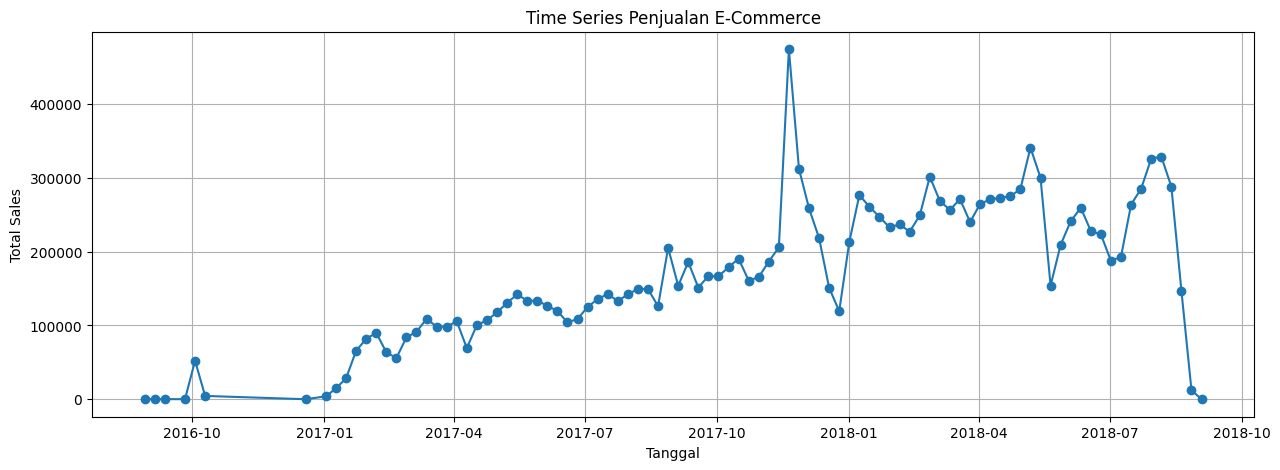

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(selected_features['week_start'], selected_features['total_sales'], marker='o')
plt.title('Time Series Penjualan E-Commerce')
plt.xlabel('Tanggal')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()


Disini terjadi lonjakan besar pada Q4, dimana pada bulan November hingga Desember biasanya ada event seperti christmas, ataupun event seperti 12.12, sehingga distribusi data seperti ini biasanya sering ditemukan pada dataset e-commerce

## Feature Engineering

In [46]:
# Pastikan week_start sudah tipe datetime dan data terurut
selected_features = selected_features.sort_values('week_start').reset_index(drop=True)

# Lag 1 minggu
selected_features['sales_lag_1'] = selected_features['total_sales'].shift(1)

# Lag 2 minggu
selected_features['sales_lag_2'] = selected_features['total_sales'].shift(2)

# Lag 4 minggu
selected_features['sales_lag_4'] = selected_features['total_sales'].shift(4)


In [47]:
# Rolling mean 4 minggu terakhir
selected_features['sales_roll_mean_4'] = selected_features['total_sales'].rolling(window=4).mean()

In [50]:
selected_features.head(50)

,week_start,total_sales,month,year,sales_lag_1,sales_lag_2,sales_lag_4,sales_roll_mean_4
0,2016-08-29,136.23,8,2016,NaN,NaN,NaN,NaN
1,2016-09-05,75.06,9,2016,136.23,NaN,NaN,NaN
2,2016-09-12,143.46,9,2016,75.06,136.23,NaN,NaN
3,2016-09-26,109.34,9,2016,143.46,75.06,NaN,116.0225
4,2016-10-03,52206.11,10,2016,109.34,143.46,136.23,13133.4925
5,2016-10-10,4493.39,10,2016,52206.11,109.34,75.06,14238.0750
6,2016-12-19,19.62,12,2016,4493.39,52206.11,143.46,14207.1150
7,2017-01-02,3953.17,1,2017,19.62,4493.39,109.34,15168.0725
8,2017-01-09,14742.33,1,2017,3953.17,19.62,52206.11,5802.1275
9,2017-01-16,28318.24,1,2017,14742.33,3953.17,4493.39,11758.3400


Lag feature adalah fitur yang berisi nilai penjualan dari minggu-minggu sebelumnya. Misalnya, sales_lag_1 berisi penjualan minggu lalu, sales_lag_2 dua minggu lalu, dan seterusnya. Fitur ini membantu model mempelajari pola historis, karena apa yang terjadi di masa lalu sering mempengaruhi penjualan di masa depan.

Rolling mean adalah rata-rata penjualan selama beberapa minggu terakhir (misal 4 minggu). Fitur ini digunakan untuk menangkap tren jangka pendek dan mengurangi efek fluktuasi mingguan yang ekstrem, sehingga model bisa mengenali pola rata-rata penjualan terbaru.

Dengan menambahkan lag feature dan rolling mean, model machine learning dapat lebih baik memahami pola waktu dan tren pada data penjualan.

## Save to Preprocessing CSV

In [51]:
import os
print(os.getcwd())

f:\Portofolio\Olist-Ml\notebooks


In [52]:
df.to_csv("../dataset/processed/cleaned_ready.csv", index=False)